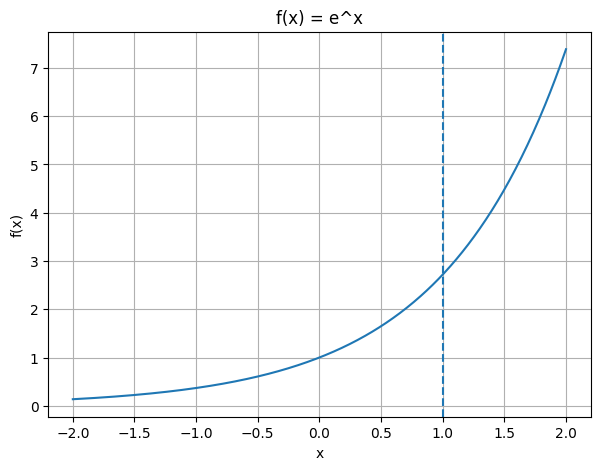

In [5]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-2, 2, 500)

y = np.exp(x)

plt.figure(figsize=(7, 5))
plt.plot(x, y)

# Evaluation point x = 1
plt.axvline(1, linestyle='--')

plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("f(x) = e^x")

plt.grid(True)
plt.show()

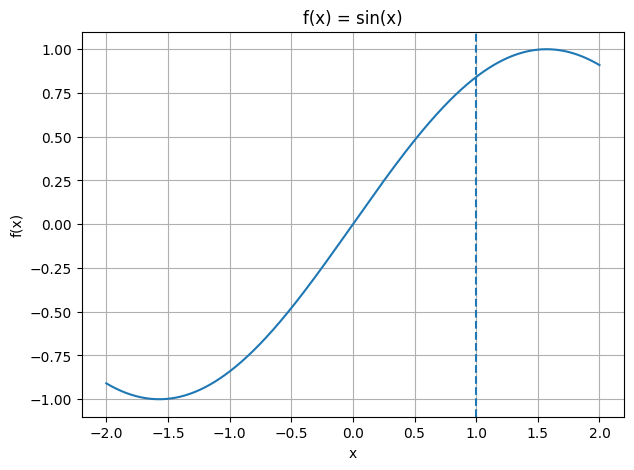

In [6]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-2, 2, 500)

y = np.sin(x)

plt.figure(figsize=(7, 5))
plt.plot(x, y)

# Evaluation point x = 1
plt.axvline(1, linestyle='--')

plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("f(x) = sin(x)")

plt.grid(True)
plt.show()

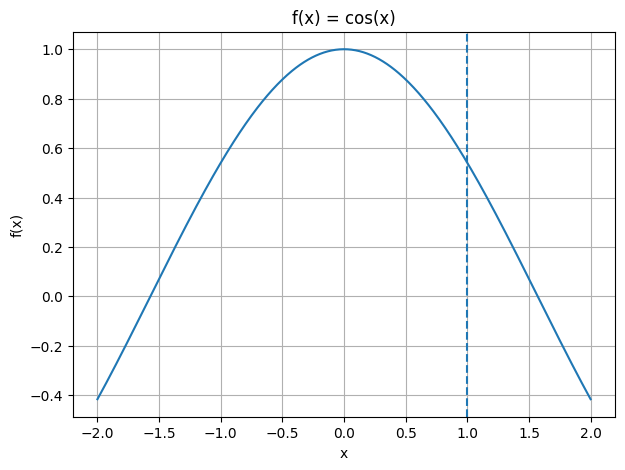

In [7]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-2, 2, 500)

y = np.cos(x)

plt.figure(figsize=(7, 5))
plt.plot(x, y)

# Evaluation point x = 1
plt.axvline(1, linestyle='--')

plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("f(x) = cos(x)")

plt.grid(True)
plt.show()

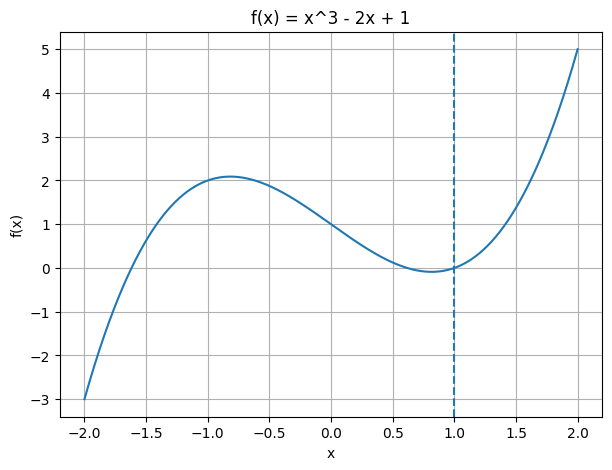

In [8]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-2, 2, 500)

y = x**3 - 2*x + 1

plt.figure(figsize=(7, 5))
plt.plot(x, y)

# Evaluation point x = 1
plt.axvline(1, linestyle='--')

plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("f(x) = x^3 - 2x + 1")

plt.grid(True)
plt.show()

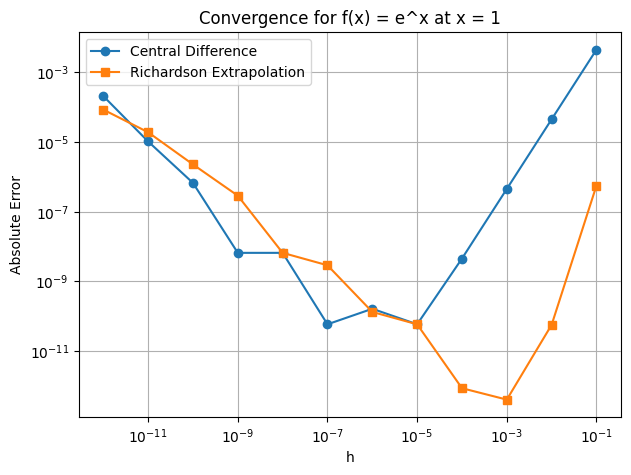

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


# Function
def f(x):
    return np.exp(x)


# Central Difference
def central_difference(f, x, h):
    return (f(x + h) - f(x - h)) / (2 * h)


# Richardson Extrapolation
def richardson(f, x, h):
    D_h = central_difference(f, x, h)
    D_h2 = central_difference(f, x, h / 2)

    return (4 * D_h2 - D_h) / 3


# Evaluation point
x = 1.0


# h = 10^-1 to 10^-12
h_values = 10.0 ** (-np.arange(1, 13))


# Exact derivative of e^x at x = 1
exact = np.exp(1)


central_error = []
richardson_error = []


for h in h_values:

    D = central_difference(f, x, h)

    R = richardson(f, x, h)

    central_error.append(abs(exact - D))

    richardson_error.append(abs(exact - R))


# Log-log convergence plot
plt.figure(figsize=(7, 5))

plt.loglog(
    h_values,
    central_error,
    'o-',
    label='Central Difference'
)

plt.loglog(
    h_values,
    richardson_error,
    's-',
    label='Richardson Extrapolation'
)

plt.xlabel('h')
plt.ylabel('Absolute Error')

plt.title('Convergence for f(x) = e^x at x = 1')

plt.legend()

plt.grid(True, which='both')

plt.show()

            f(x) = e^x: slope D = 2.000 (theory 2)   slope R = 4.000 (theory 4)


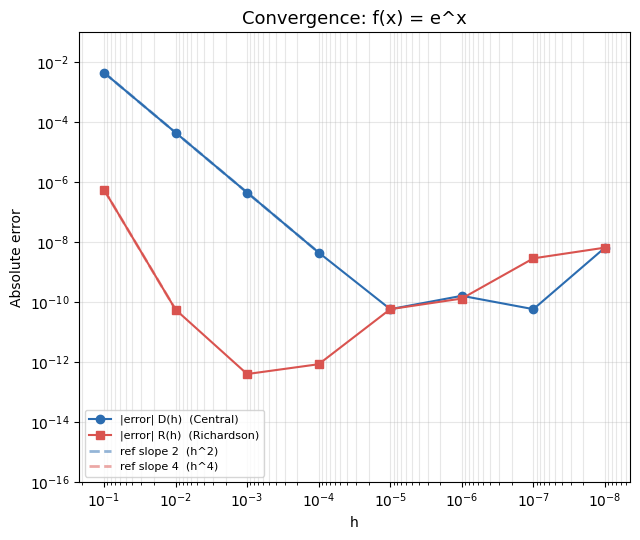

         f(x) = sin(x): slope D = 2.000 (theory 2)   slope R = 4.000 (theory 4)


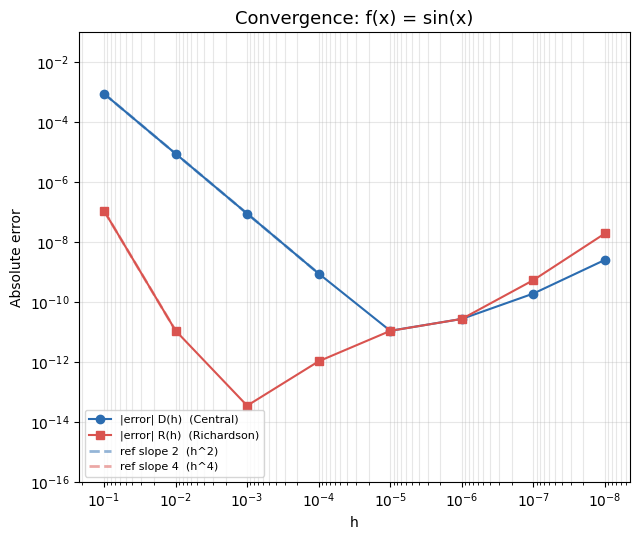

         f(x) = cos(x): slope D = 2.000 (theory 2)   slope R = 4.000 (theory 4)


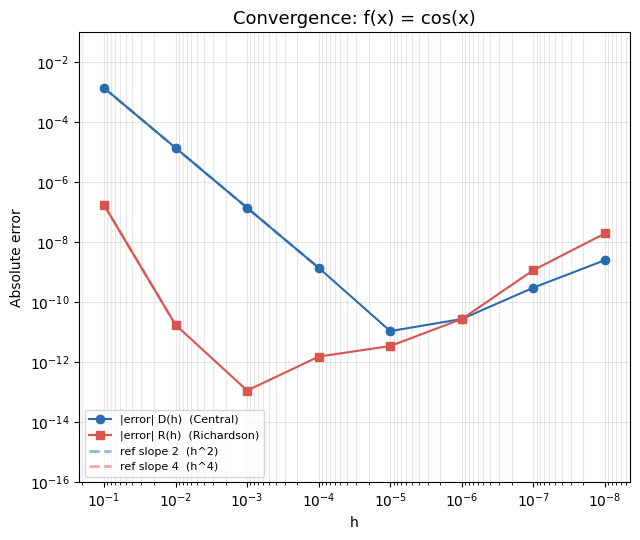

   f(x) = x^3 - 2x + 1: slope D = 2.000 (theory 2)   slope R = -1.097 (theory 4)


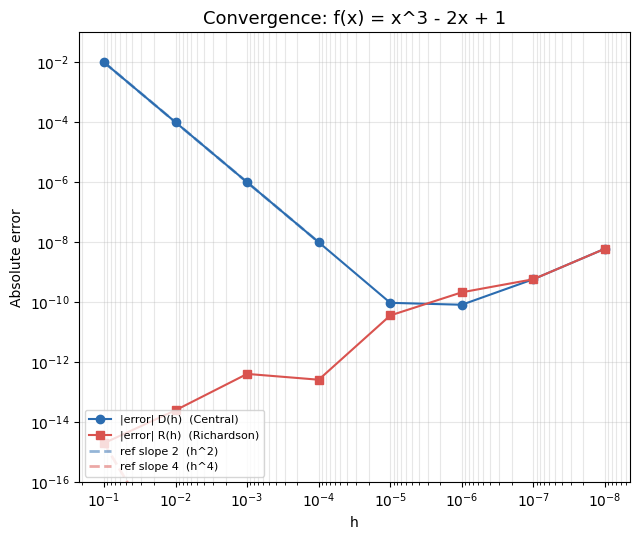

In [13]:

 
"""
Individual log-log convergence plots (one figure per function):
|error| vs h for Central Difference D(h) and Richardson R(h).
"""

import numpy as np
import matplotlib.pyplot as plt

funcs = {
    "exp":  (lambda x: np.exp(x),         lambda x: np.exp(x),      "f(x) = e^x"),
    "sin":  (lambda x: np.sin(x),          lambda x: np.cos(x),      "f(x) = sin(x)"),
    "cos":  (lambda x: np.cos(x),          lambda x: -np.sin(x),     "f(x) = cos(x)"),
    "poly": (lambda x: x**3 - 2*x + 1,     lambda x: 3*x**2 - 2,     "f(x) = x^3 - 2x + 1"),
}

x0 = 1.0
hs = np.array([10.0**(-k) for k in range(1, 9)])  # h = 1e-1 ... 1e-8


def central_diff(f, x, h):
    return (f(x + h) - f(x - h)) / (2 * h)


def richardson(f, x, h):
    D_h  = central_diff(f, x, h)
    D_h2 = central_diff(f, x, h / 2.0)
    return (4 * D_h2 - D_h) / 3.0


for name, (f, fp, label) in funcs.items():
    exact = fp(x0)
    errD = np.array([abs(exact - central_diff(f, x0, h)) for h in hs])
    errR = np.array([abs(exact - richardson(f, x0, h))   for h in hs])

    fig, ax = plt.subplots(figsize=(6.5, 5.5))
    ax.loglog(hs, errD, "o-", color="#2b6cb0", label="|error| D(h)  (Central)")
    ax.loglog(hs, errR, "s-", color="#d9534f", label="|error| R(h)  (Richardson)")

    # reference slope lines over the pre-round-off window
    C2 = errD[0] / hs[0]**2
    C4 = errR[0] / hs[0]**4
    hs_ref_D = hs[0:4]   # 1e-1 .. 1e-4
    hs_ref_R = hs[0:2]   # 1e-1 .. 1e-2
    ax.loglog(hs_ref_D, C2 * hs_ref_D**2, "--", color="#2b6cb0", alpha=0.5, lw=2, label="ref slope 2  (h^2)")
    ax.loglog(hs_ref_R, C4 * hs_ref_R**4, "--", color="#d9534f", alpha=0.5, lw=2, label="ref slope 4  (h^4)")

    slopeD = np.polyfit(np.log10(hs[0:4]), np.log10(errD[0:4]), 1)[0]
    slopeR = np.polyfit(np.log10(hs[0:2]), np.log10(errR[0:2]), 1)[0]
    print(f"{label:>22}: slope D = {slopeD:.3f} (theory 2)   slope R = {slopeR:.3f} (theory 4)")

    ax.set_title(f"Convergence: {label}", fontsize=13)
    ax.set_xlabel("h")
    ax.set_ylabel("Absolute error")
    ax.set_ylim(1e-16, 1e-1)
    ax.invert_xaxis()
    ax.grid(which="both", alpha=0.3)
    ax.legend(fontsize=8, loc="lower left")
    fig.tight_layout()
    fig.savefig(f"convergence_{name}.png", dpi=150)
    plt.show()